# Taxonomy Visualization by Barcode and Farm Type

This notebook visualizes metagenomic taxonomy data from Ukrainian farm wastewater samples.

**Data Source**: `taxonomy_barcode_bacteria.csv` and `barcode_farm_mapping.csv`

**Farm Types**: Poultry (4 samples) vs Pig (20 samples)  
**Sample Types**: Native vs Enriched  
**Regions**: Zaporizhzhia, Zhytomyr, Kyiv, Chernivtsi, Vinnytsia, Mykolaiv Oblasts

## 1. Setup & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Try to import plotly for interactive visualizations
try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly not available. Install with: pip install plotly")

# Plotting style configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Color palette
COLORS = {
    'Poultry': '#2ecc71',  # Green
    'Pig': '#e74c3c',      # Red
    'Native': '#3498db',   # Blue
    'Enriched': '#9b59b6'  # Purple
}

# Taxonomy level order
TAXON_LEVELS = ['phylum', 'class', 'order', 'family', 'genus', 'species']

print("Setup complete!")

Setup complete!


## 2. Load Data

In [2]:
from google.colab import files
uploaded = files.upload()

Saving taxonomy_barcode_bacteria.csv to taxonomy_barcode_bacteria.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving barcode_farm_mapping.csv to barcode_farm_mapping.csv


In [4]:
# Load taxonomy data
# df = pd.read_csv('taxonomy_barcode_bacteria.csv')
df = pd.read_csv('taxonomy_barcode_bacteria.csv')

# Load barcode mapping
mapping = pd.read_csv('barcode_farm_mapping.csv')

print(f"Taxonomy data shape: {df.shape}")
print(f"Mapping data shape: {mapping.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nTaxon levels: {df['taxon_level'].unique().tolist()}")
print(f"\nFarm types: {df['farm_type'].unique().tolist()}")
print(f"\nSample types: {df['sample_type'].unique().tolist()}")

Taxonomy data shape: (6442, 9)
Mapping data shape: (24, 7)

Columns: ['barcode', 'farm_type', 'farm_id', 'sample_type', 'oblast', 'taxon_level', 'taxon_name', 'abundance', 'full_taxonomy']

Taxon levels: ['class', 'family', 'genus', 'order', 'phylum', 'species']

Farm types: ['Poultry', 'Pig']

Sample types: ['Native', 'Enriched']


In [5]:
# Data overview
df.head(10)

,barcode,farm_type,farm_id,sample_type,oblast,taxon_level,taxon_name,abundance,full_taxonomy
0,barcode01,Poultry,poultry #1,Native,Zaporizhzhia Oblast,class,Bacteroidia,186,Bacteria;Bacteria_none;Bacteroidota;Bacteroidia
1,barcode01,Poultry,poultry #1,Native,Zaporizhzhia Oblast,class,Betaproteobacteria,1027,Bacteria;Bacteria_none;Pseudomonadota;Betaprot...
2,barcode01,Poultry,poultry #1,Native,Zaporizhzhia Oblast,class,Clostridia,65,Bacteria;Bacteria_none;Bacillota;Clostridia
3,barcode01,Poultry,poultry #1,Native,Zaporizhzhia Oblast,class,Gammaproteobacteria,11187,Bacteria;Bacteria_none;Pseudomonadota;Gammapro...
4,barcode01,Poultry,poultry #1,Native,Zaporizhzhia Oblast,class,Unknown,2510,Unclassified;Unknown;Unknown;Unknown
5,barcode01,Poultry,poultry #1,Native,Zaporizhzhia Oblast,family,Aeromonadaceae,197,Bacteria;Bacteria_none;Pseudomonadota;Gammapro...
6,barcode01,Poultry,poultry #1,Native,Zaporizhzhia Oblast,family,Anaerotignaceae,15,Bacteria;Bacteria_none;Bacillota;Clostridia;La...
7,barcode01,Poultry,poultry #1,Native,Zaporizhzhia Oblast,family,Bacteroidaceae,75,Bacteria;Bacteria_none;Bacteroidota;Bacteroidi...
8,barcode01,Poultry,poultry #1,Native,Zaporizhzhia Oblast,family,Comamonadaceae,1027,Bacteria;Bacteria_none;Pseudomonadota;Betaprot...
9,barcode01,Poultry,poultry #1,Native,Zaporizhzhia Oblast,family,Enterobacteriaceae,8272,Bacteria;Bacteria_none;Pseudomonadota;Gammapro...


In [6]:
# Summary statistics
print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"\nTotal records: {len(df):,}")
print(f"Unique barcodes: {df['barcode'].nunique()}")
print(f"Unique taxa: {df['taxon_name'].nunique()}")

print("\nRecords per taxon level:")
print(df.groupby('taxon_level').size().reindex(TAXON_LEVELS))

print("\nSamples per farm type:")
print(df.groupby('farm_type')['barcode'].nunique())

DATA SUMMARY

Total records: 6,442
Unique barcodes: 24
Unique taxa: 2131

Records per taxon level:
taxon_level
phylum      196
class       276
order       469
family      763
genus      1431
species    3307
dtype: int64

Samples per farm type:
farm_type
Pig        18
Poultry     6
Name: barcode, dtype: int64


---
## 3. Barcode → Taxonomy Visualizations

### 3.1 Phylum Composition per Barcode (Stacked Bar)

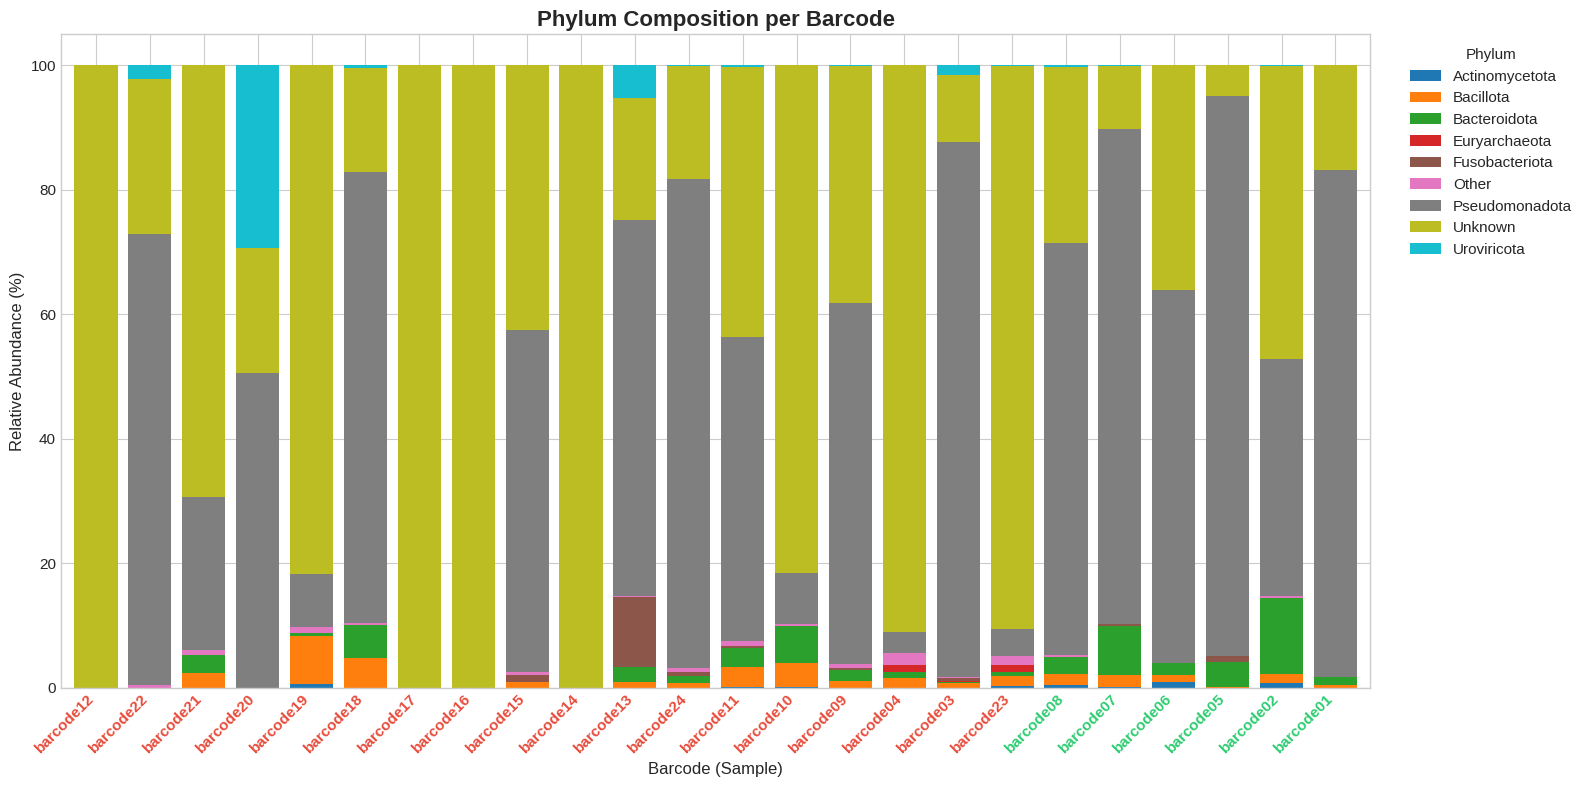


X-axis label colors: Green = Poultry, Red = Pig


In [7]:
# Filter to phylum level only
df_phylum = df[df['taxon_level'] == 'phylum'].copy()

# Calculate relative abundance per barcode
barcode_totals = df_phylum.groupby('barcode')['abundance'].sum()
df_phylum['relative_abundance'] = df_phylum.apply(
    lambda x: x['abundance'] / barcode_totals[x['barcode']] * 100, axis=1
)

# Get top phyla (by total abundance)
top_phyla = df_phylum.groupby('taxon_name')['abundance'].sum().nlargest(8).index.tolist()

# Group remaining as 'Other'
df_phylum['taxon_display'] = df_phylum['taxon_name'].apply(
    lambda x: x if x in top_phyla else 'Other'
)

# Pivot for stacked bar
pivot = df_phylum.pivot_table(
    index='barcode',
    columns='taxon_display',
    values='relative_abundance',
    aggfunc='sum',
    fill_value=0
)

# Sort by farm type
barcode_order = mapping.sort_values('farm_type')['barcode'].tolist()
pivot = pivot.reindex(barcode_order)

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', width=0.8)

ax.set_xlabel('Barcode (Sample)')
ax.set_ylabel('Relative Abundance (%)')
ax.set_title('Phylum Composition per Barcode', fontsize=16, fontweight='bold')
ax.legend(title='Phylum', bbox_to_anchor=(1.02, 1), loc='upper left')

# Color x-axis labels by farm type
farm_type_map = mapping.set_index('barcode')['farm_type'].to_dict()
for i, label in enumerate(ax.get_xticklabels()):
    barcode = label.get_text()
    color = COLORS.get(farm_type_map.get(barcode, ''), 'black')
    label.set_color(color)
    label.set_fontweight('bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nX-axis label colors: Green = Poultry, Red = Pig")

### 3.2 Top Genera Abundance Heatmap

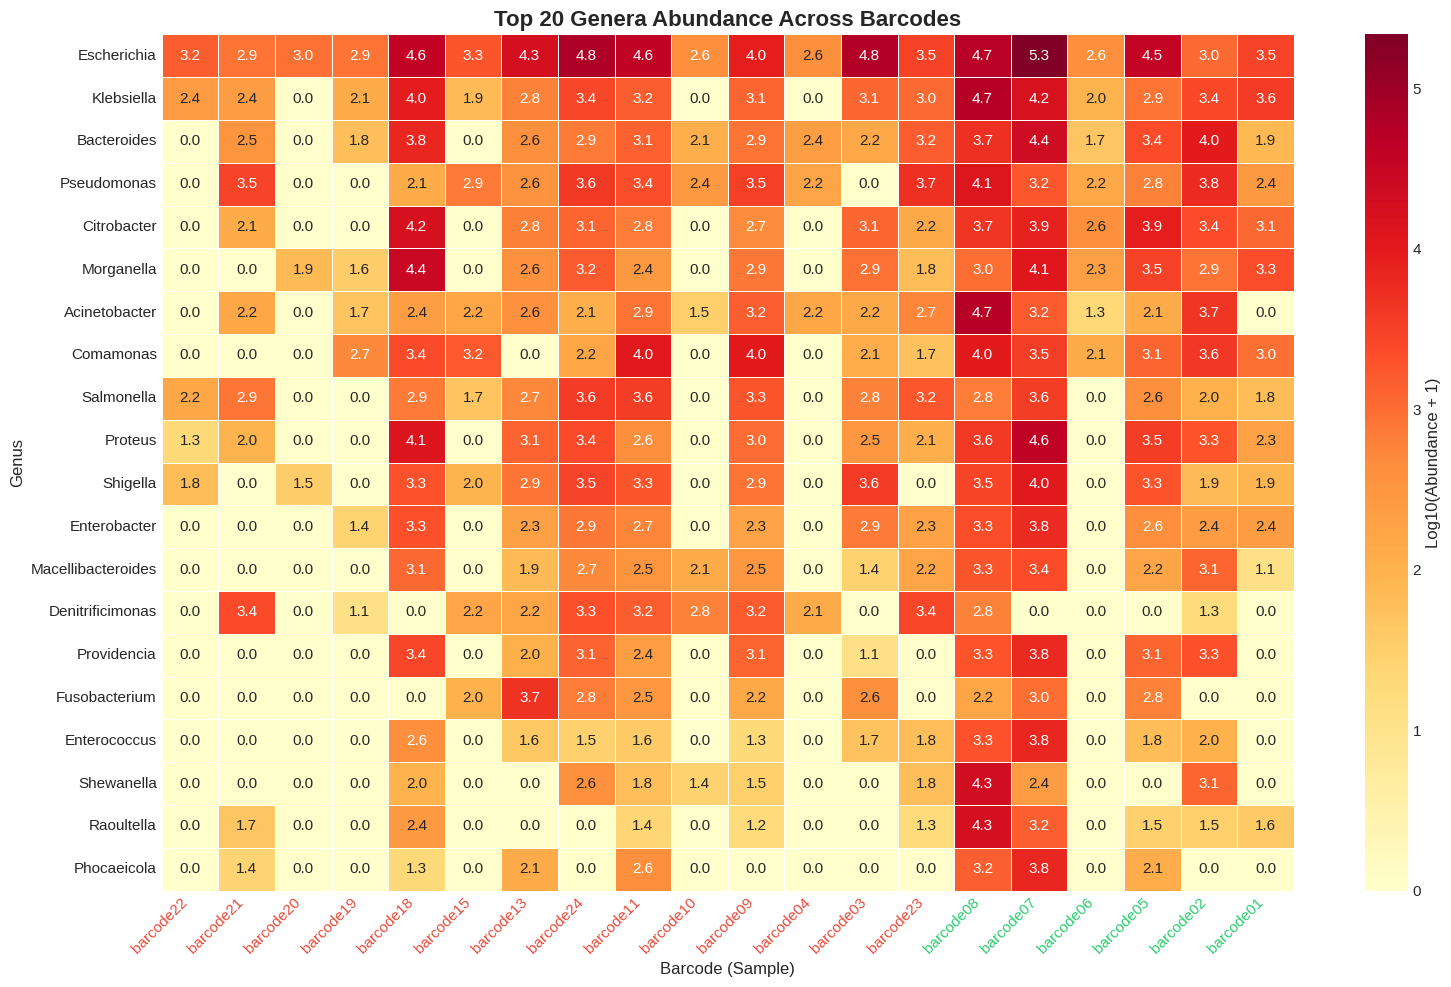

X-axis colors: Green = Poultry, Red = Pig


In [8]:
# Filter to genus level
df_genus = df[df['taxon_level'] == 'genus'].copy()

# Exclude 'Unknown'
df_genus = df_genus[df_genus['taxon_name'] != 'Unknown']

# Get top 20 genera by total abundance
top_genera = df_genus.groupby('taxon_name')['abundance'].sum().nlargest(20).index.tolist()
df_top = df_genus[df_genus['taxon_name'].isin(top_genera)]

# Create pivot table
heatmap_data = df_top.pivot_table(
    index='taxon_name',
    columns='barcode',
    values='abundance',
    fill_value=0
)

# Log transform for better visualization
heatmap_log = np.log10(heatmap_data + 1)

# Sort columns by farm type
barcode_order = mapping.sort_values('farm_type')['barcode'].tolist()
valid_barcodes = [b for b in barcode_order if b in heatmap_log.columns]
heatmap_log = heatmap_log[valid_barcodes]

# Sort rows by total abundance
row_order = heatmap_log.sum(axis=1).sort_values(ascending=False).index
heatmap_log = heatmap_log.loc[row_order]

# Plot
fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    heatmap_log,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Log10(Abundance + 1)'},
    linewidths=0.5,
    annot=True,
    fmt=".1f",
)

ax.set_title('Top 20 Genera Abundance Across Barcodes', fontsize=16, fontweight='bold')
ax.set_xlabel('Barcode (Sample)')
ax.set_ylabel('Genus')

# Color x-axis labels by farm type
for label in ax.get_xticklabels():
    barcode = label.get_text()
    color = COLORS.get(farm_type_map.get(barcode, ''), 'black')
    label.set_color(color)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("X-axis colors: Green = Poultry, Red = Pig")

### 3.3 Interactive Sunburst: Taxonomy Hierarchy

In [9]:
if PLOTLY_AVAILABLE:
    # Prepare data for sunburst - use genus level with hierarchy
    df_sunburst = df[df['taxon_level'] == 'genus'].copy()
    df_sunburst = df_sunburst[df_sunburst['taxon_name'] != 'Unknown']

    # Parse full_taxonomy to get hierarchy
    df_sunburst['superkingdom'] = df_sunburst['full_taxonomy'].str.split(';').str[0]
    df_sunburst['phylum'] = df_sunburst['full_taxonomy'].str.split(';').str[2]
    df_sunburst['class'] = df_sunburst['full_taxonomy'].str.split(';').str[3]

    # Aggregate by farm type
    sunburst_data = df_sunburst.groupby(
        ['farm_type', 'superkingdom', 'phylum', 'class', 'taxon_name']
    )['abundance'].sum().reset_index()

    # Filter to top genera per farm type
    top_per_farm = sunburst_data.groupby('farm_type').apply(
        lambda x: x.nlargest(30, 'abundance')
    ).reset_index(drop=True)

    # Create sunburst
    fig = px.sunburst(
        top_per_farm,
        path=['farm_type', 'phylum', 'class', 'taxon_name'],
        values='abundance',
        color='farm_type',
        color_discrete_map=COLORS,
        title='Taxonomy Hierarchy by Farm Type (Top 30 Genera)'
    )

    fig.update_layout(
        font=dict(size=12),
        width=900,
        height=900
    )

    fig.show()
else:
    print("Plotly not available. Skipping interactive sunburst visualization.")
    print("Install with: pip install plotly")

/tmp/ipykernel_262/1133779219.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_per_farm = sunburst_data.groupby('farm_type').apply(


---
## 4. Farm Type Comparison (Pig vs Poultry)

### 4.1 Top Taxa by Farm Type

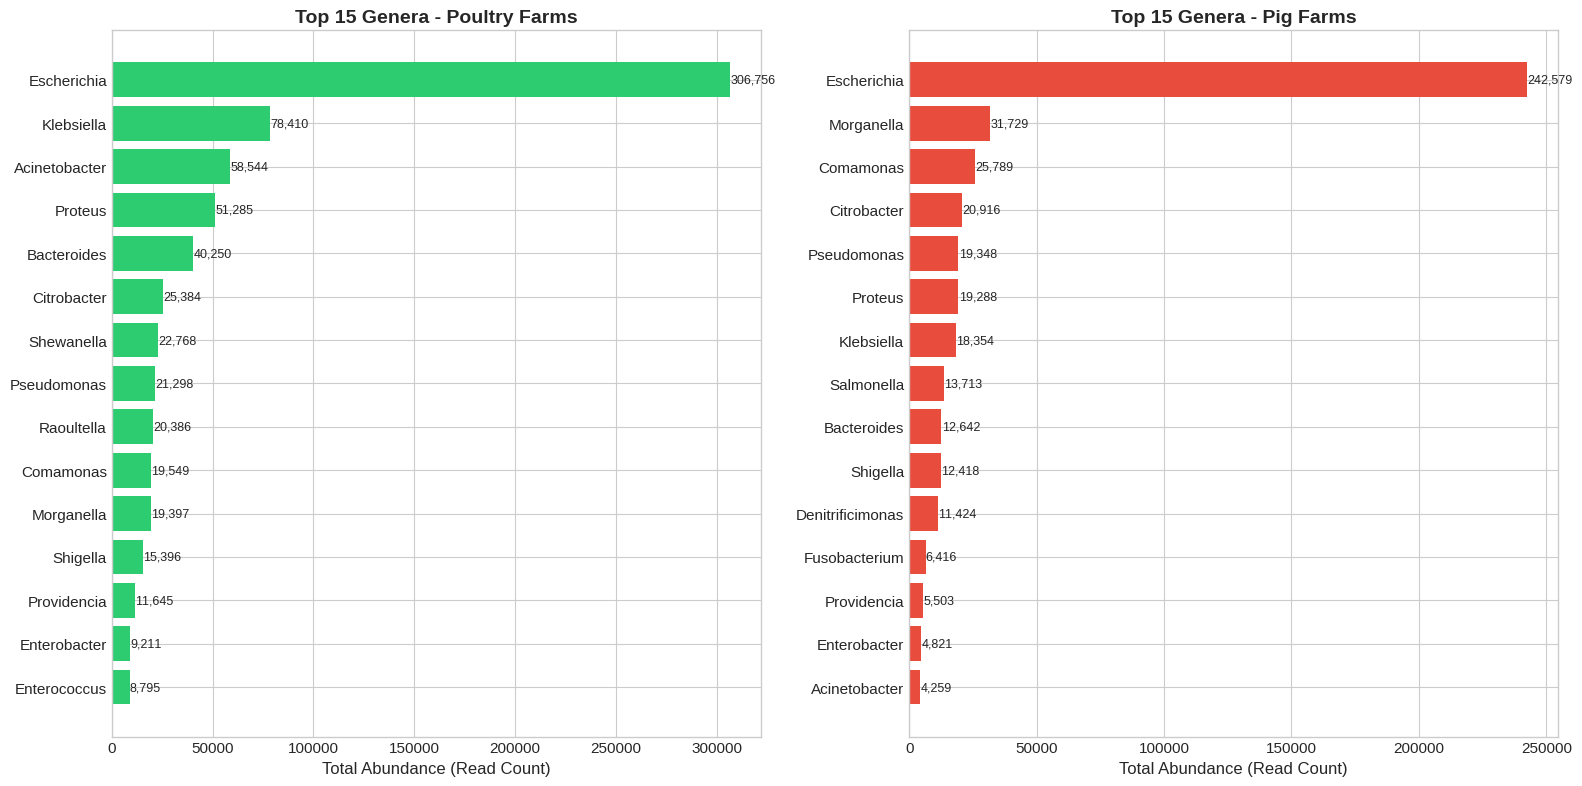

In [10]:
# Aggregate genus abundance by farm type
df_genus = df[df['taxon_level'] == 'genus'].copy()
df_genus = df_genus[df_genus['taxon_name'] != 'Unknown']

genus_by_farm = df_genus.groupby(['farm_type', 'taxon_name'])['abundance'].sum().reset_index()

# Get top 15 for each farm type
top_poultry = genus_by_farm[genus_by_farm['farm_type'] == 'Poultry'].nlargest(15, 'abundance')
top_pig = genus_by_farm[genus_by_farm['farm_type'] == 'Pig'].nlargest(15, 'abundance')

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Poultry
axes[0].barh(top_poultry['taxon_name'], top_poultry['abundance'], color=COLORS['Poultry'])
axes[0].set_xlabel('Total Abundance (Read Count)')
axes[0].set_title('Top 15 Genera - Poultry Farms', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(top_poultry['abundance']):
    axes[0].text(v + 100, i, f'{v:,.0f}', va='center', fontsize=9)

# Pig
axes[1].barh(top_pig['taxon_name'], top_pig['abundance'], color=COLORS['Pig'])
axes[1].set_xlabel('Total Abundance (Read Count)')
axes[1].set_title('Top 15 Genera - Pig Farms', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(top_pig['abundance']):
    axes[1].text(v + 100, i, f'{v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 4.2 Diversity Metrics by Farm Type

/tmp/ipykernel_262/1410683334.py:41: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_262/1410683334.py:48: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_262/1410683334.py:55: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




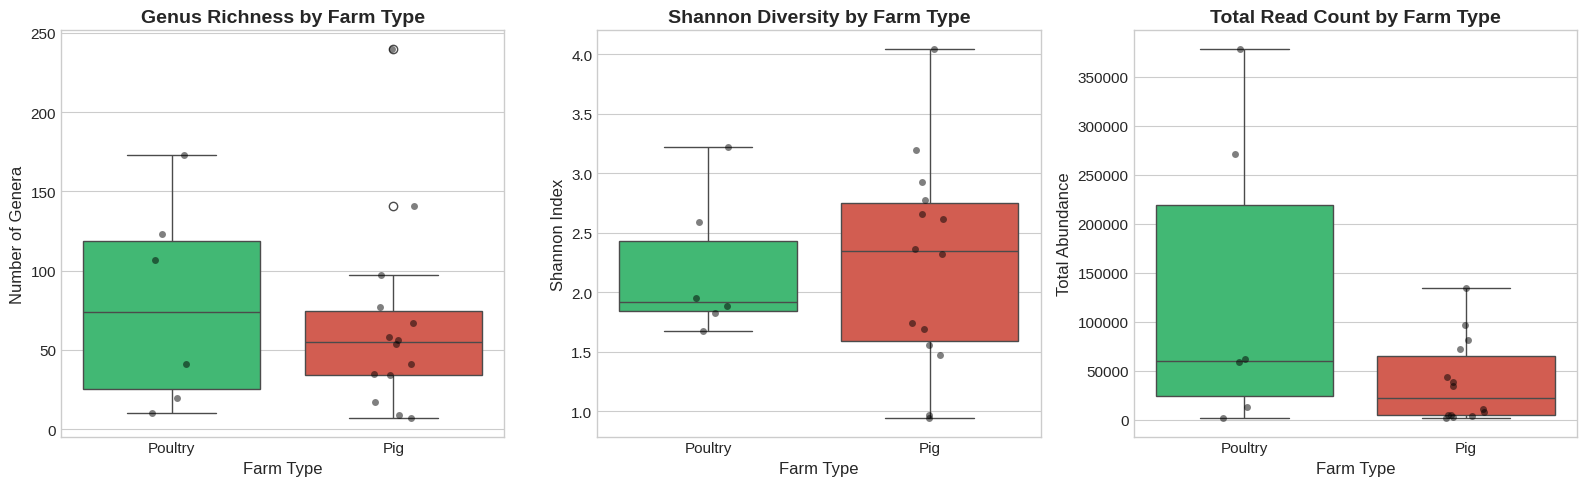


Diversity Metrics Summary:
          richness                                                shannon  \
             count   mean    std   min    25%   50%    75%    max   count   
farm_type                                                                   
Pig           14.0  66.64  61.41   7.0  34.25  55.0   74.5  240.0    14.0   
Poultry        6.0  79.00  65.18  10.0  25.25  74.0  119.0  173.0     6.0   

                 ...             total_abundance                        \
           mean  ...   75%   max           count       mean        std   
farm_type        ...                                                     
Pig        2.24  ...  2.75  4.04            14.0   38299.07   42321.46   
Poultry    2.19  ...  2.43  3.22             6.0  130665.17  156138.31   

                                                          
              min      25%      50%        75%       max  
farm_type                                                 
Pig        2088.0   4673.0  22405.5   

In [11]:
# Calculate diversity metrics per barcode
df_genus = df[df['taxon_level'] == 'genus'].copy()
df_genus = df_genus[df_genus['taxon_name'] != 'Unknown']

diversity_metrics = []

for barcode in df_genus['barcode'].unique():
    barcode_data = df_genus[df_genus['barcode'] == barcode]

    # Richness (number of unique genera)
    richness = barcode_data['taxon_name'].nunique()

    # Shannon diversity index
    abundances = barcode_data['abundance'].values
    total = abundances.sum()
    if total > 0:
        proportions = abundances / total
        shannon = -np.sum(proportions * np.log(proportions + 1e-10))
    else:
        shannon = 0

    # Get metadata
    meta = mapping[mapping['barcode'] == barcode].iloc[0]

    diversity_metrics.append({
        'barcode': barcode,
        'farm_type': meta['farm_type'],
        'sample_type': meta['sample_type'],
        'oblast': meta['oblast'],
        'richness': richness,
        'shannon': shannon,
        'total_abundance': total
    })

div_df = pd.DataFrame(diversity_metrics)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Richness
sns.boxplot(data=div_df, x='farm_type', y='richness', palette=COLORS, ax=axes[0])
sns.stripplot(data=div_df, x='farm_type', y='richness', color='black', alpha=0.5, ax=axes[0])
axes[0].set_title('Genus Richness by Farm Type', fontweight='bold')
axes[0].set_xlabel('Farm Type')
axes[0].set_ylabel('Number of Genera')

# Shannon
sns.boxplot(data=div_df, x='farm_type', y='shannon', palette=COLORS, ax=axes[1])
sns.stripplot(data=div_df, x='farm_type', y='shannon', color='black', alpha=0.5, ax=axes[1])
axes[1].set_title('Shannon Diversity by Farm Type', fontweight='bold')
axes[1].set_xlabel('Farm Type')
axes[1].set_ylabel('Shannon Index')

# Total abundance
sns.boxplot(data=div_df, x='farm_type', y='total_abundance', palette=COLORS, ax=axes[2])
sns.stripplot(data=div_df, x='farm_type', y='total_abundance', color='black', alpha=0.5, ax=axes[2])
axes[2].set_title('Total Read Count by Farm Type', fontweight='bold')
axes[2].set_xlabel('Farm Type')
axes[2].set_ylabel('Total Abundance')

plt.tight_layout()
plt.show()

# Print summary
print("\nDiversity Metrics Summary:")
print(div_df.groupby('farm_type')[['richness', 'shannon', 'total_abundance']].describe().round(2))

### 4.3 Differential Abundance: Pig vs Poultry

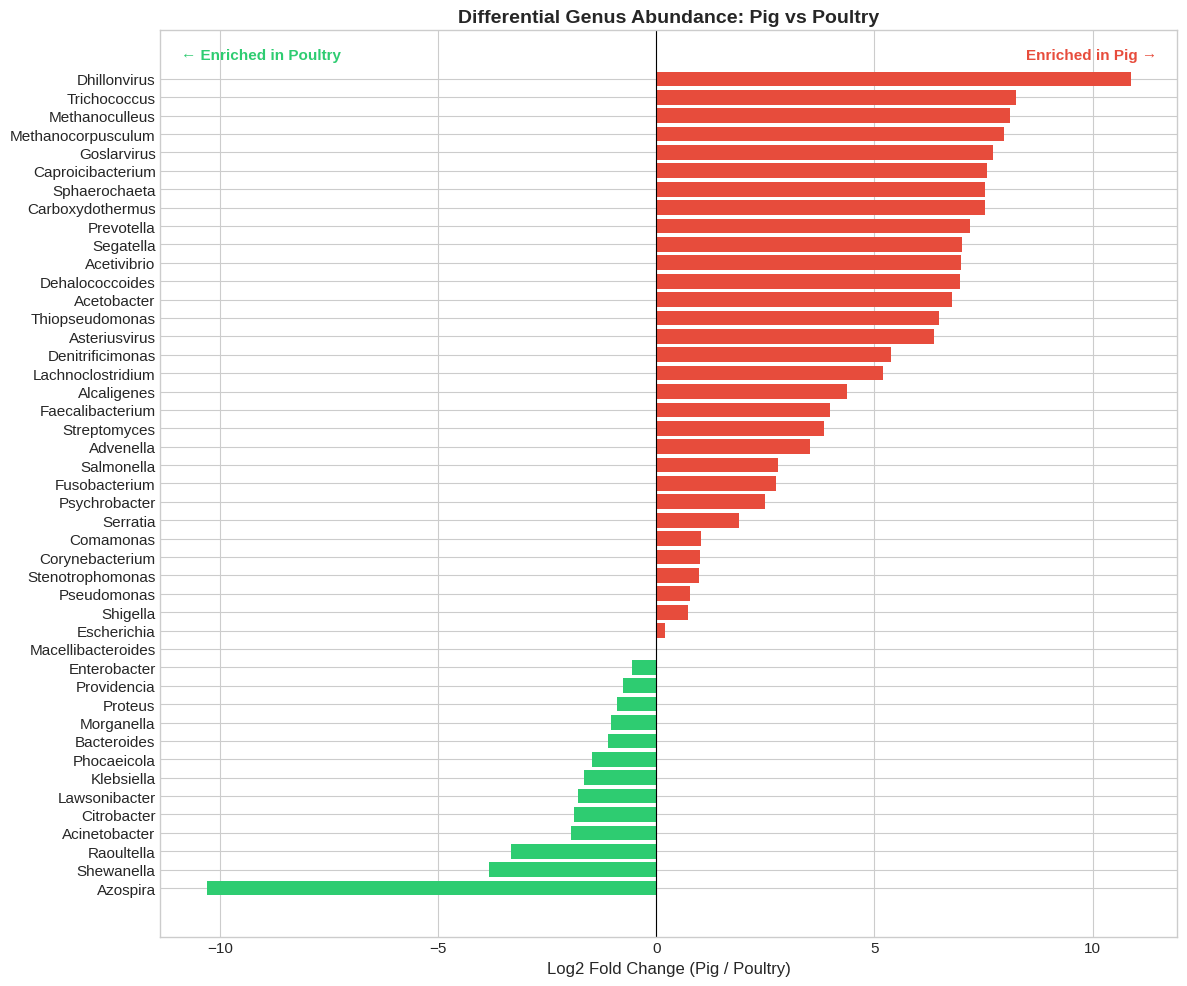

In [12]:
# Calculate mean relative abundance per farm type
df_genus = df[df['taxon_level'] == 'genus'].copy()
df_genus = df_genus[df_genus['taxon_name'] != 'Unknown']

# Normalize within each barcode
barcode_totals = df_genus.groupby('barcode')['abundance'].sum()
df_genus['rel_abundance'] = df_genus.apply(
    lambda x: x['abundance'] / barcode_totals[x['barcode']] * 100, axis=1
)

# Mean per farm type
mean_by_farm = df_genus.groupby(['farm_type', 'taxon_name'])['rel_abundance'].mean().reset_index()
pivot_farm = mean_by_farm.pivot(index='taxon_name', columns='farm_type', values='rel_abundance').fillna(0)

# Calculate log fold change
pivot_farm['log2FC'] = np.log2((pivot_farm['Pig'] + 0.01) / (pivot_farm['Poultry'] + 0.01))
pivot_farm['mean_abundance'] = (pivot_farm['Pig'] + pivot_farm['Poultry']) / 2

# Filter to abundant genera
pivot_farm = pivot_farm[pivot_farm['mean_abundance'] > 0.5]

# Sort by fold change
pivot_farm = pivot_farm.sort_values('log2FC')

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

colors = [COLORS['Pig'] if x > 0 else COLORS['Poultry'] for x in pivot_farm['log2FC']]
ax.barh(pivot_farm.index, pivot_farm['log2FC'], color=colors)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Log2 Fold Change (Pig / Poultry)')
ax.set_title('Differential Genus Abundance: Pig vs Poultry', fontsize=14, fontweight='bold')

# Add annotation
ax.text(0.02, 0.98, '← Enriched in Poultry', transform=ax.transAxes,
        color=COLORS['Poultry'], fontweight='bold', va='top')
ax.text(0.98, 0.98, 'Enriched in Pig →', transform=ax.transAxes,
        color=COLORS['Pig'], fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.show()

---
## 5. Sample Type Analysis (Native vs Enriched)

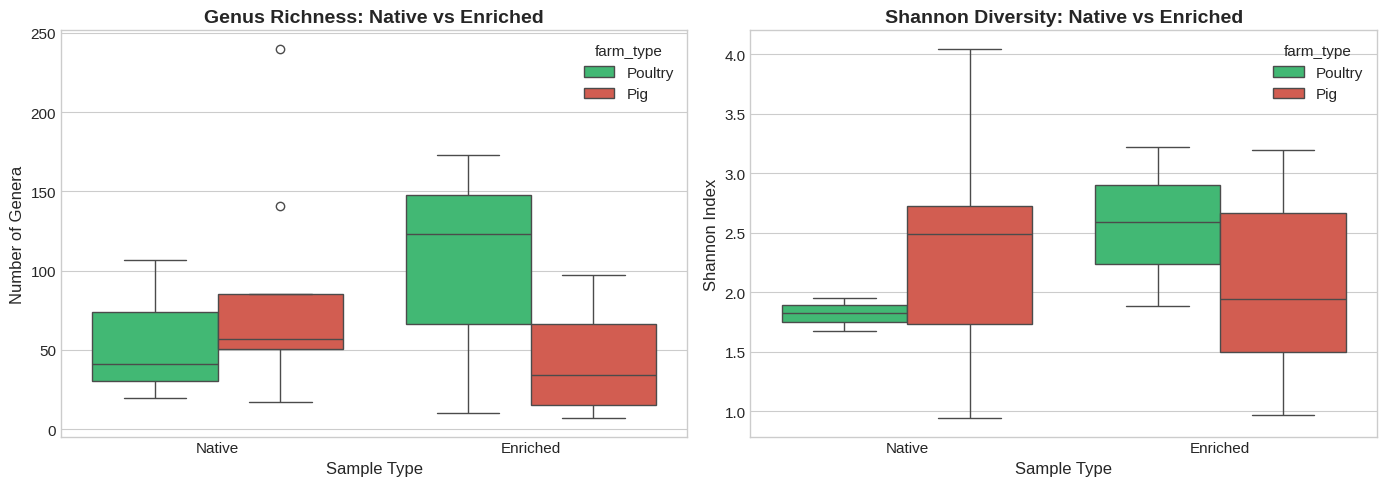


Diversity by Sample Type and Farm Type:
                       richness  shannon
farm_type sample_type                   
Pig       Enriched        43.17     2.05
          Native          84.25     2.37
Poultry   Enriched       102.00     2.56
          Native          56.00     1.82


In [13]:
# Diversity by sample type and farm type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Richness
sns.boxplot(
    data=div_df,
    x='sample_type',
    y='richness',
    hue='farm_type',
    palette=COLORS,
    ax=axes[0]
)
axes[0].set_title('Genus Richness: Native vs Enriched', fontweight='bold')
axes[0].set_xlabel('Sample Type')
axes[0].set_ylabel('Number of Genera')

# Shannon
sns.boxplot(
    data=div_df,
    x='sample_type',
    y='shannon',
    hue='farm_type',
    palette=COLORS,
    ax=axes[1]
)
axes[1].set_title('Shannon Diversity: Native vs Enriched', fontweight='bold')
axes[1].set_xlabel('Sample Type')
axes[1].set_ylabel('Shannon Index')

plt.tight_layout()
plt.show()

# Summary
print("\nDiversity by Sample Type and Farm Type:")
print(div_df.groupby(['farm_type', 'sample_type'])[['richness', 'shannon']].mean().round(2))

---
## 6. Regional Analysis (by Oblast)

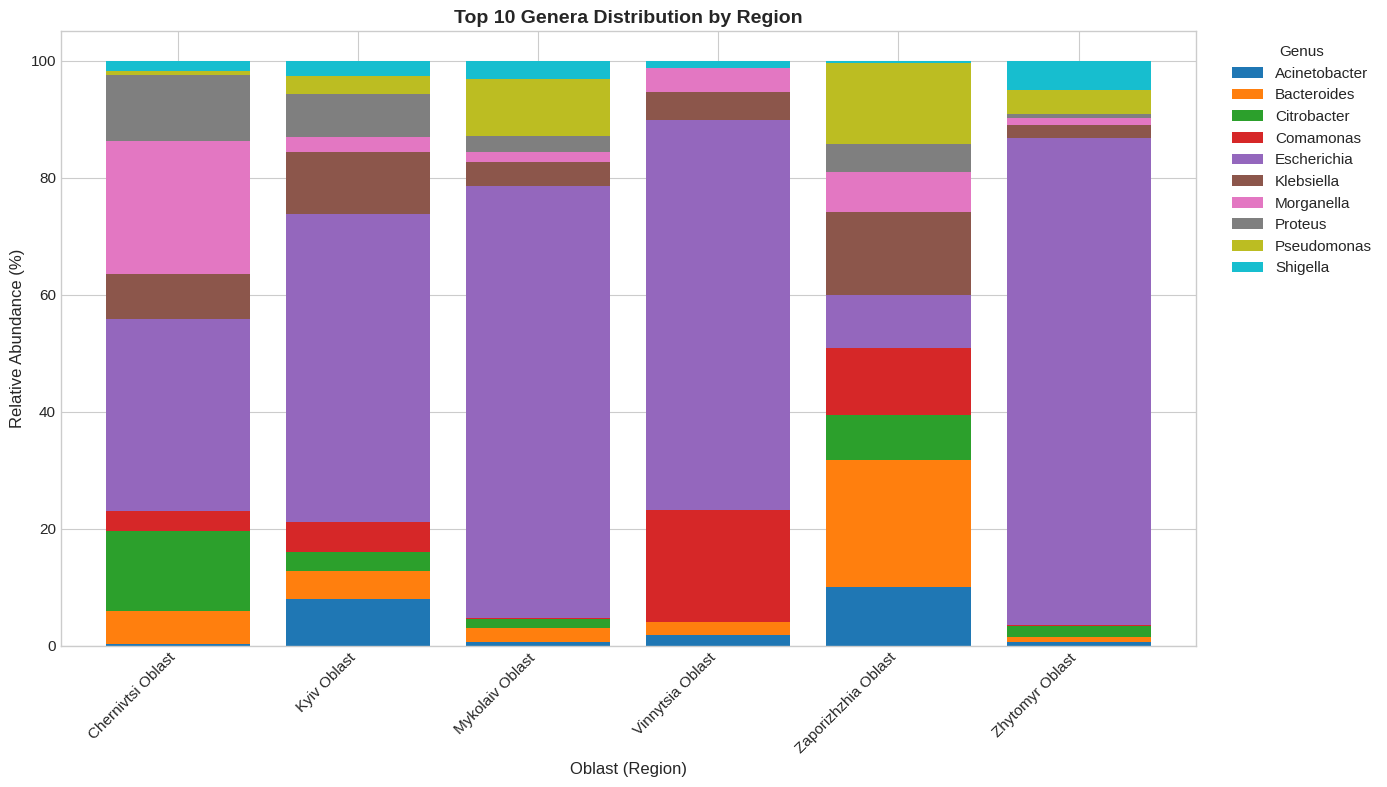


Samples per Oblast:
oblast
Chernivtsi Oblast       4
Kyiv Oblast            10
Mykolaiv Oblast         2
Vinnytsia Oblast        2
Zaporizhzhia Oblast     2
Zhytomyr Oblast         4
Name: barcode, dtype: int64


In [14]:
# Taxa distribution by oblast
df_genus = df[df['taxon_level'] == 'genus'].copy()
df_genus = df_genus[df_genus['taxon_name'] != 'Unknown']

# Get top genera
top_genera = df_genus.groupby('taxon_name')['abundance'].sum().nlargest(10).index.tolist()
df_top = df_genus[df_genus['taxon_name'].isin(top_genera)]

# Aggregate by oblast
oblast_data = df_top.groupby(['oblast', 'taxon_name'])['abundance'].sum().reset_index()

# Pivot
oblast_pivot = oblast_data.pivot(index='oblast', columns='taxon_name', values='abundance').fillna(0)

# Normalize to percentages
oblast_pct = oblast_pivot.div(oblast_pivot.sum(axis=1), axis=0) * 100

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
oblast_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', width=0.8)

ax.set_xlabel('Oblast (Region)')
ax.set_ylabel('Relative Abundance (%)')
ax.set_title('Top 10 Genera Distribution by Region', fontsize=14, fontweight='bold')
ax.legend(title='Genus', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Sample counts per oblast
print("\nSamples per Oblast:")
print(mapping.groupby('oblast')['barcode'].count())

---
## 7. Summary Statistics

In [15]:
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(f"\n📊 DATASET OVERVIEW")
print(f"   Total samples (barcodes): {df['barcode'].nunique()}")
print(f"   Total taxonomy records: {len(df):,}")

print(f"\n🏠 FARM TYPES")
for farm_type in ['Poultry', 'Pig']:
    count = mapping[mapping['farm_type'] == farm_type].shape[0]
    print(f"   {farm_type}: {count} samples")

print(f"\n🧬 TAXONOMY COUNTS")
for level in TAXON_LEVELS:
    count = df[df['taxon_level'] == level]['taxon_name'].nunique()
    print(f"   Unique {level}: {count}")

print(f"\n🔬 TOP 10 MOST ABUNDANT GENERA")
df_genus = df[(df['taxon_level'] == 'genus') & (df['taxon_name'] != 'Unknown')]
top_genera = df_genus.groupby('taxon_name')['abundance'].sum().nlargest(10)
for i, (genus, count) in enumerate(top_genera.items(), 1):
    print(f"   {i:2}. {genus}: {count:,} reads")

print(f"\n📍 REGIONS")
for oblast in mapping['oblast'].unique():
    count = mapping[mapping['oblast'] == oblast].shape[0]
    print(f"   {oblast}: {count} samples")

print("\n" + "=" * 70)

FINAL SUMMARY

📊 DATASET OVERVIEW
   Total samples (barcodes): 24
   Total taxonomy records: 6,442

🏠 FARM TYPES
   Poultry: 6 samples
   Pig: 18 samples

🧬 TAXONOMY COUNTS
   Unique phylum: 31
   Unique class: 53
   Unique order: 103
   Unique family: 213
   Unique genus: 472
   Unique species: 1267

🔬 TOP 10 MOST ABUNDANT GENERA
    1. Escherichia: 549,335 reads
    2. Klebsiella: 96,764 reads
    3. Proteus: 70,573 reads
    4. Acinetobacter: 62,803 reads
    5. Bacteroides: 52,892 reads
    6. Morganella: 51,126 reads
    7. Citrobacter: 46,300 reads
    8. Comamonas: 45,338 reads
    9. Pseudomonas: 40,646 reads
   10. Shigella: 27,814 reads

📍 REGIONS
   Zaporizhzhia Oblast: 2 samples
   Zhytomyr Oblast: 4 samples
   Kyiv Oblast: 10 samples
   Chernivtsi Oblast: 4 samples
   Vinnytsia Oblast: 2 samples
   Mykolaiv Oblast: 2 samples



---
## 8. Diversity Analysis (Rarefied Data)

This section uses **rarefied diversity indices** from `diversity_indices.csv`.

**Why rarefied data?**
- Raw abundance counts are biased by sequencing depth
- Samples with more reads appear more diverse (artifact, not biology)
- Rarefaction normalizes all samples to the same depth for fair comparison

**Diversity Indices:**
- **Shannon Index**: Higher = more diverse communities
- **Simpson's Index**: Probability two individuals are different species
- **Richness**: Total number of unique taxa
- **Pielou's Evenness**: How evenly distributed are species (0-1)

8.1 Shannon Diversity by Farm Type

In [ ]:
# Load diversity indices from rarefied data
# For Google Colab:
import pandas as pd

from google.colab import files
uploaded = files.upload()  # Upload diversity_indices.csv

# For local:
diversity_df = pd.read_csv('diversity_indices.csv')

print(f"Diversity data shape: {diversity_df.shape}")
print(f"\nColumns: {diversity_df.columns.tolist()}")
diversity_df.head()

8.2 Richness by Farm Type

In [ ]:
# Shannon and Simpson diversity by farm type
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Shannon Index
sns.boxplot(data=diversity_df, x='farm_type', y='shannon_index', palette=COLORS, ax=axes[0])
sns.stripplot(data=diversity_df, x='farm_type', y='shannon_index', color='black', alpha=0.6, size=8, ax=axes[0])
axes[0].set_title('Shannon Diversity Index by Farm Type\n(Rarefied Data)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Farm Type')
axes[0].set_ylabel('Shannon Index')
axes[0].axhline(y=diversity_df['shannon_index'].median(), color='gray', linestyle='--', alpha=0.5, label='Overall Median')
axes[0].legend()

# Simpson Index
sns.boxplot(data=diversity_df, x='farm_type', y='simpson_index', palette=COLORS, ax=axes[1])
sns.stripplot(data=diversity_df, x='farm_type', y='simpson_index', color='black', alpha=0.6, size=8, ax=axes[1])
axes[1].set_title("Simpson's Index by Farm Type\n(Rarefied Data)", fontsize=14, fontweight='bold')
axes[1].set_xlabel('Farm Type')
axes[1].set_ylabel("Simpson's Index")

plt.tight_layout()
plt.show()

# Summary statistics
print("\nDiversity Summary by Farm Type:")
print(diversity_df.groupby('farm_type')[['shannon_index', 'simpson_index', 'richness']].agg(['mean', 'std', 'median']).round(2))

8.3 Shannon vs Richness Scatter

In [ ]:
# Richness comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Richness by farm type
sns.boxplot(data=diversity_df, x='farm_type', y='richness', palette=COLORS, ax=axes[0])
sns.stripplot(data=diversity_df, x='farm_type', y='richness', color='black', alpha=0.6, size=8, ax=axes[0])
axes[0].set_title('Taxa Richness by Farm Type\n(Number of Unique Taxa)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Farm Type')
axes[0].set_ylabel('Richness')

# Richness by farm type and sample type
sns.boxplot(data=diversity_df, x='farm_type', y='richness', hue='sample_type', palette={'Native': COLORS['Native'], 'Enriched': COLORS['Enriched']}, ax=axes[1])
axes[1].set_title('Taxa Richness: Farm Type × Sample Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Farm Type')
axes[1].set_ylabel('Richness')

plt.tight_layout()
plt.show()

8.4 Diversity by Region (Oblast)

In [ ]:
# Shannon vs Richness scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

for farm_type in ['Poultry', 'Pig']:
    subset = diversity_df[diversity_df['farm_type'] == farm_type]
    ax.scatter(
        subset['richness'],
        subset['shannon_index'],
        c=COLORS[farm_type],
        s=100,
        alpha=0.7,
        label=farm_type,
        edgecolors='white',
        linewidths=1
    )

    # Add barcode labels
    for _, row in subset.iterrows():
        ax.annotate(
            row['barcode'].replace('barcode', 'BC'),
            (row['richness'], row['shannon_index']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            alpha=0.7
        )

ax.set_xlabel('Richness (Number of Taxa)', fontsize=12)
ax.set_ylabel('Shannon Diversity Index', fontsize=12)
ax.set_title('Shannon Diversity vs Richness\n(Rarefied Data)', fontsize=14, fontweight='bold')
ax.legend(title='Farm Type')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

8.5 Statistical Test: Mann-Whitney U

In [ ]:
# Diversity by region
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Order oblasts by sample count
oblast_order = diversity_df.groupby('oblast').size().sort_values(ascending=False).index.tolist()

# Shannon by oblast
sns.barplot(
    data=diversity_df,
    x='oblast',
    y='shannon_index',
    hue='farm_type',
    palette=COLORS,
    order=oblast_order,
    ax=axes[0]
)
axes[0].set_title('Shannon Index by Region', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Oblast (Region)')
axes[0].set_ylabel('Shannon Index')
axes[0].tick_params(axis='x', rotation=45)

# Richness by oblast
sns.barplot(
    data=diversity_df,
    x='oblast',
    y='richness',
    hue='farm_type',
    palette=COLORS,
    order=oblast_order,
    ax=axes[1]
)
axes[1].set_title('Taxa Richness by Region', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Oblast (Region)')
axes[1].set_ylabel('Richness')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary
print("\nDiversity by Region:")
print(diversity_df.groupby('oblast')[['shannon_index', 'richness']].agg(['mean', 'count']).round(2))

8.6 All Diversity Indices Heatmap

In [ ]:
# Statistical comparison: Mann-Whitney U test (non-parametric)
from scipy import stats

print("=" * 60)
print("STATISTICAL COMPARISON: PIG vs POULTRY")
print("Mann-Whitney U Test (non-parametric)")
print("=" * 60)

poultry = diversity_df[diversity_df['farm_type'] == 'Poultry']
pig = diversity_df[diversity_df['farm_type'] == 'Pig']

metrics = ['shannon_index', 'simpson_index', 'richness', 'pielou_evenness']
metric_names = ['Shannon Index', "Simpson's Index", 'Richness', "Pielou's Evenness"]

for metric, name in zip(metrics, metric_names):
    # Get values, dropping NaN
    poultry_vals = poultry[metric].dropna()
    pig_vals = pig[metric].dropna()

    if len(poultry_vals) > 0 and len(pig_vals) > 0:
        stat, p_value = stats.mannwhitneyu(poultry_vals, pig_vals, alternative='two-sided')

        significance = ""
        if p_value < 0.001:
            significance = "***"
        elif p_value < 0.01:
            significance = "**"
        elif p_value < 0.05:
            significance = "*"
        else:
            significance = "ns"

        print(f"\n{name}:")
        print(f"  Poultry (n={len(poultry_vals)}): mean={poultry_vals.mean():.2f}, median={poultry_vals.median():.2f}")
        print(f"  Pig (n={len(pig_vals)}): mean={pig_vals.mean():.2f}, median={pig_vals.median():.2f}")
        print(f"  U-statistic: {stat:.2f}, p-value: {p_value:.4f} {significance}")

print("\n" + "-" * 60)
print("Significance levels: * p<0.05, ** p<0.01, *** p<0.001, ns = not significant")

In [ ]:
# Heatmap of all diversity indices
diversity_cols = ['shannon_index', 'simpson_index', 'pielou_evenness', 'richness', 'effective_species']

# Prepare data
heatmap_df = diversity_df.set_index('barcode')[diversity_cols].copy()

# Normalize each column to 0-1 for fair comparison
heatmap_normalized = (heatmap_df - heatmap_df.min()) / (heatmap_df.max() - heatmap_df.min())

# Sort by farm type
barcode_order = diversity_df.sort_values(['farm_type', 'barcode'])['barcode'].tolist()
heatmap_normalized = heatmap_normalized.loc[barcode_order]

# Rename columns for display
col_names = {
    'shannon_index': 'Shannon',
    'simpson_index': 'Simpson',
    'pielou_evenness': 'Evenness',
    'richness': 'Richness',
    'effective_species': 'Eff. Species'
}
heatmap_normalized = heatmap_normalized.rename(columns=col_names)

# Plot
fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(
    heatmap_normalized,
    cmap='RdYlGn',
    ax=ax,
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'Normalized Value (0-1)'},
    linewidths=0.5
)

ax.set_title('Diversity Indices by Sample\n(Normalized, Green = High, Red = Low)', fontsize=14, fontweight='bold')
ax.set_xlabel('Diversity Index')
ax.set_ylabel('Barcode (Sample)')

# Color y-axis labels by farm type
farm_type_map = diversity_df.set_index('barcode')['farm_type'].to_dict()
for label in ax.get_yticklabels():
    barcode = label.get_text()
    color = COLORS.get(farm_type_map.get(barcode, ''), 'black')
    label.set_color(color)

plt.tight_layout()
plt.show()

print("\nY-axis colors: Green = Poultry, Red = Pig")